### Downloading ResNet18


In [ ]:
import torch
import torchvision
from torchvision import transforms


net = torchvision.models.resnet18(pretrained=True) #download the pretrained model right away
print(net)
ps = sum(param.nelement() for param in net.parameters())
print(f"{ps:,d} parameters")
print()

weights = torchvision.models.ResNet18_Weights.DEFAULT #
print(f"Weights: {weights}")
print()

preprocess = weights.transforms() #
print(f"Prerpocess: {preprocess}")
print()

imagenet_classes = torchvision.models.resnet._IMAGENET_CATEGORIES

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#Transforming the data

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Resnet wants 224x224 -> randomly cropping
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),  # 15 degrees, variability
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),  # adding variability (10%)
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], # mean values RGB from Image NET
                         [0.229, 0.224, 0.225]) # standart deviation (sigma) from Image Net
                                                # model trained on IN that had inputs normalized this way,
                                                # so in our case we have to nomralize the same
])


val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


#Creating the loaders

In [ ]:

import google.colab
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

google.colab.drive.mount('/content/drive', force_remount=True)
PROJECT_DIR = '/content/drive/MyDrive/DL_PROJECT/lung_colon_image_set_split/'

train_set = ImageFolder(PROJECT_DIR + "train", transform=train_transform)
val_set = ImageFolder(PROJECT_DIR + "val", transform=val_transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, drop_last=True, num_workers=2) #shuffle important,
                                                                                                 #change the order,
# we drop the batch if we cant fulfill 64, 2 threads for loading data
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, drop_last=False, num_workers=2)


images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")


Mounted at /content/drive
Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])


#Showing the batch

['lung_scc', 'colon_n', 'lung_scc', 'lung_n', 'colon_aca', 'lung_scc', 'lung_aca', 'colon_aca', 'lung_n', 'colon_n', 'lung_scc', 'lung_n']
torch.Size([12, 3, 224, 224])


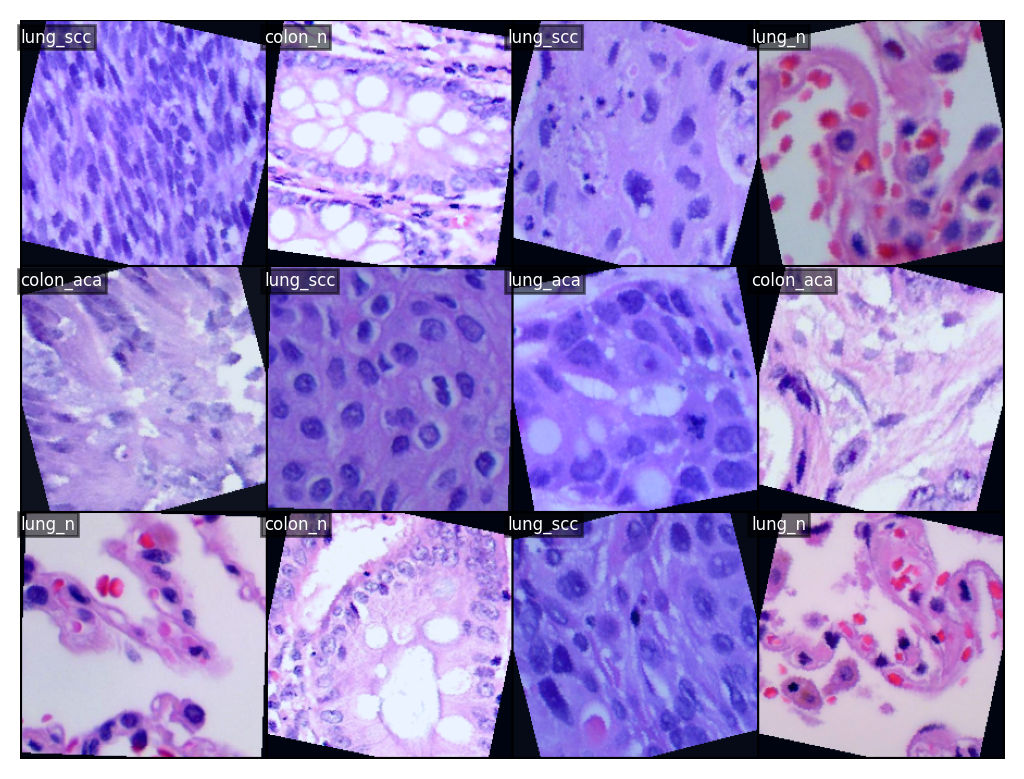

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
images = images[:12]
labels = labels[:12]
plt.figure(dpi=200)
grid = torchvision.utils.make_grid(images, nrow=4, normalize=True).permute(1, 2, 0) #nrow defines cols actually +
#normalize so we dont show norm we did + we permute for plotlib (224x224x3)
plt.axis("off")
plt.imshow(grid)
print([train_set.classes[i] for i in labels])
print(images.shape)




nrow = 4
cell_size = 224  # because all images are 224x224
for n in range(12): #
    row = n // nrow # it can be either 0, 1, 2, 3 --> 30//8 = 3
    col = n % nrow # 30%8 = 6, 6%8 = 6 --> we describe the col
    label_text = train_set.classes[labels[n]] # we match correct label here
    x = col * cell_size # we apply the same logic from above, but we take the image size into consideration
                        # (without it the shift is to small [look at the values])
    y = row * cell_size + 20
    plt.text(x, y, label_text, fontsize=6, color='white', bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.show()

#Transfer Learning

In [ ]:
LR = 0.001
DEVICE = ("cuda" if torch.cuda.is_available() else "cpu")
loss_fun = torch.nn.CrossEntropyLoss().to(DEVICE)

net.fc = torch.nn.Linear(512, len(train_set.classes))
net = net.to(DEVICE)

optimizer = torch.optim.Adam(net.fc.parameters(), lr=LR)

for param in net.parameters():
    param.requires_grad = False

for param in net.fc.parameters():
    param.requires_grad = True



In [ ]:
print(DEVICE)

cuda


###Training last layer

In [ ]:
import time
import copy

EPOCHS = 3
best_model_wts = copy.deepcopy(net.state_dict()) # for storing the current best weights of the model
best_acc = 0.0

train_losses = []
val_losses = []

since = time.time() # lets start measuring the time

for epoch in range(EPOCHS):
    print(f"Epoch {epoch}/{EPOCHS}")
    print("-" * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            net.train()
            dataloader = train_loader
        else:
            net.eval()
            dataloader = val_loader

        running_loss = 0.0 # total loss for current phase
        running_corrects = 0 # total corrects for cp

        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'): # if phase val, we disable grad for speed and memory usage
                outputs = net(images)
                loss = loss_fun(outputs, labels)
                _, preds = torch.max(outputs, 1) # max value and index of that value

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * images.size(0) # loss.item is average loss of image in the batch,
                                                         # image.size is num in the batch; we accumulate value
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset) # after all of the batches, divide by num in epoch
        epoch_acc = running_corrects.double() / len(dataloader.dataset) # double = float64, for division

        if phase == 'train':
            train_losses.append(epoch_loss)
        else:
            val_losses.append(epoch_loss)

        print(f"{phase.capitalize()} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(net.state_dict())

print("=" * 30)
print(f"Training complete. Best val Acc: {best_acc:.4f}")

time_elapsed = time.time() - since
print(f"Training time: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

# Load best model
net.load_state_dict(best_model_wts)


Epoch 0/3
----------
Train Loss: 0.2675  Acc: 0.9035
Val Loss: 0.1786  Acc: 0.9356
Epoch 1/3
----------
Train Loss: 0.2379  Acc: 0.9116
Val Loss: 0.1608  Acc: 0.9458
Epoch 2/3
----------
Train Loss: 0.2168  Acc: 0.9180
Val Loss: 0.1402  Acc: 0.9508
Training complete. Best val Acc: 0.9508
Training time: 29m 29s


<All keys matched successfully>

In [ ]:
torch.save(net.state_dict(), "/content/drive/MyDrive/DL_PROJECT/best_model.pth")


### Loading saved model

In [ ]:
import torch.nn as nn # we skipped the cell of training that is why we have to initialize some things again

DEVICE = ("cuda" if torch.cuda.is_available() else "cpu")
net.fc = nn.Linear(512, len(train_set.classes))
net.load_state_dict(torch.load("/content/drive/MyDrive/DL_PROJECT/best_model.pth"))
net = net.to(DEVICE)
net.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

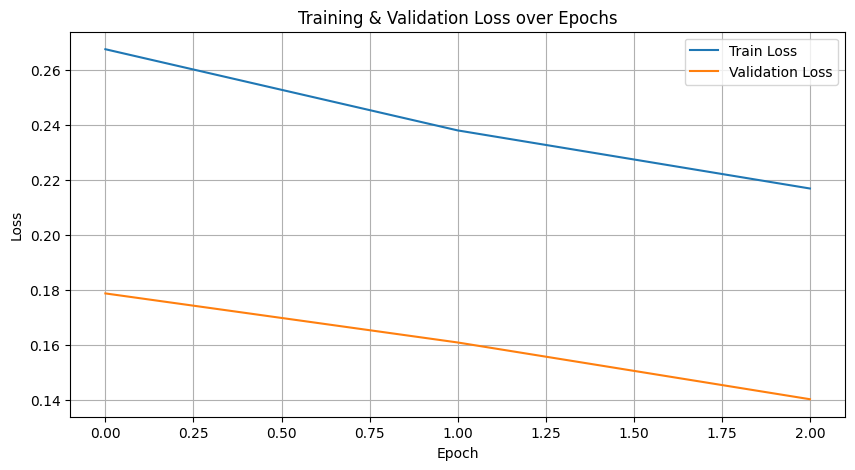

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


#Evaluation

In [ ]:
import torch.nn.functional as F

nclasses = len(train_set.classes)
cm = torch.zeros(nclasses, nclasses, dtype=torch.long) # confusion matrix initialized by zero
net.eval()

all_images = []
all_labels = []
all_preds = []

worst_cases = []

for images, labels in val_loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    with torch.no_grad():
        logits = net(images)
        probs = F.softmax(logits, dim=1)
        predictions = logits.argmax(1)

    for i in range(len(labels)):
        true = labels[i].item()
        pred = predictions[i].item()
        confidence = probs[i][pred].item() #the percentage how confident the model was

        if pred != true: #we take in all the mistakes
            worst_cases.append({
                "image": images[i].cpu(),
                "true": true,
                "pred": pred,
                "confidence": confidence
            })


    counts = torch.bincount(labels * nclasses + predictions, minlength=nclasses ** 2) # index for each pair:
                                                                                      # (true class, predicted class)
    cm += counts.view(nclasses, nclasses).cpu() # we do the matrix and accumulate

    all_images.append(images.cpu())
    all_labels.extend(labels.cpu().numpy()) # if append, we would be having list of arrays, now just solid one array
    all_preds.extend(predictions.cpu().numpy())

accuracy = cm.diag().sum() / cm.sum()
print(f"Accuracy: {100 * accuracy:.1f}%")


Accuracy: 95.1%


###Confusion Matrix

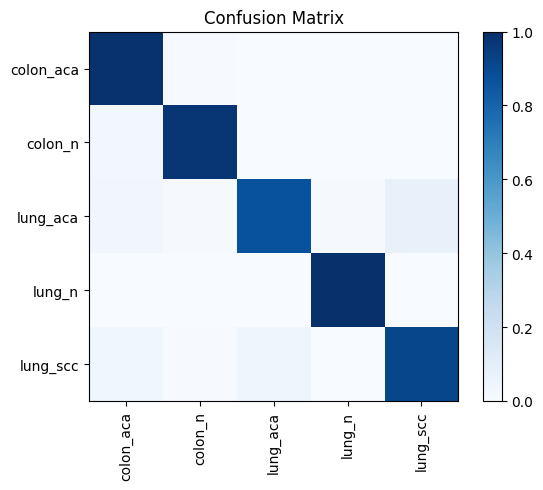

In [ ]:
cmnorm = cm.float() / cm.sum(1, keepdim=True)  # normalized => not counts, but probabilities
S
plt.figure(dpi=100)
plt.imshow(cmnorm, cmap="Blues")
plt.xticks(range(nclasses), train_set.classes, rotation=90)
plt.yticks(range(nclasses), train_set.classes)
plt.colorbar()
plt.title("Confusion Matrix")
plt.show()


###Visualizing Predictions
we show model prediction, if prediction wrong, color of font is red.

In [ ]:
images, labels = next(iter(val_loader))
images = images[:12]
labels = labels[:12]
images, labels = images.to(DEVICE), labels.to(DEVICE)


with torch.no_grad():
    outputs = net(images)
predictions = outputs.argmax(1) # gives the INDEX, not value
predictions = predictions[:12]

def show_batch(images, labels, predictions, class_names, nrow=4, cell_size=224):
  plt.figure(dpi=100)
  grid = torchvision.utils.make_grid(images.cpu(), nrow=nrow, normalize=True).permute(1, 2, 0) #nrow defines cols actually +
  #normalize so we dont show norm we did + we permute for plotlib (224x224x3)
  plt.axis("off")

  for n in range(12): #
    row = n // nrow # it can be either 0, 1, 2, 3 --> 30//8 = 3
    col = n % nrow # 30%8 = 6, 6%8 = 6 --> we describe the col


    x = col * cell_size # we apply the same logic from above, but we take the image size into consideration
                        # (without it the shift is to small [look at the values])

    y = row * cell_size + 20

    pred = predictions[n].item()
    true = labels[n].item()

    color = "lightgreen" if pred == true else "red"
    txt = class_names[pred]

    plt.text(x, y, txt, fontsize=6, color=color, bbox=dict(facecolor='black', alpha=0.5, pad=1))

  plt.show()

In [ ]:
import matplotlib.pyplot as plt

torch.cuda.empty_cache() # fixing memory crash

class_names = train_set.classes
show_batch(images, labels, predictions, class_names)

###Other Metrics (Precision, Recall, F1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=train_set.classes))

              precision    recall  f1-score   support

   colon_aca       0.91      0.99      0.95      1000
     colon_n       0.98      0.98      0.98      1000
    lung_aca       0.95      0.87      0.91      1000
      lung_n       0.99      1.00      1.00      1000
    lung_scc       0.92      0.91      0.92      1000

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



###Top 5 worst predictions

In [ ]:
worst_cases = sorted(worst_cases, key=lambda x: x['confidence'], reverse=True) # with the highest confidence first => worst mistake


def show_worst_predictions(worst_cases, class_names, k=8, cell_size=224, nrow=4):
    images = torch.stack([case["image"] for case in worst_cases[:k]]) # because we stack them like this [k, 3, 224, 224]
    labels = [case["true"] for case in worst_cases[:k]] # we iterate thrugh worst cases (list of dictionaries), but using only key true in this case
    preds = [case["pred"] for case in worst_cases[:k]]
    confs = [case["confidence"] for case in worst_cases[:k]]

    plt.figure(figsize=(18, 12))
    grid = torchvision.utils.make_grid(images, nrow=4, normalize=True).permute(1, 2, 0)
    plt.imshow(grid)
    plt.axis("off")

    for n in range(len(labels)):

      row = n // nrow # it can be either 0, 1, 2, 3 --> 30//8 = 3
      col = n % nrow # 30%8 = 6, 6%8 = 6 --> we describe the col

      x = col * cell_size + 20 # we apply the same logic from above, but we take the image size into consideration
                        # (without it the shift is to small [look at the values])

      y = row * cell_size + 30

      txt = f"{class_names[preds[n]]} ({confs[n]*100:.1f}%)\nTrue: {class_names[labels[n]]}" # class predicted, with what confidence and then the real one
      plt.text(x, y, txt, fontsize=10, color="red", bbox=dict(facecolor='black', alpha=0.6, pad=2))

    plt.show()

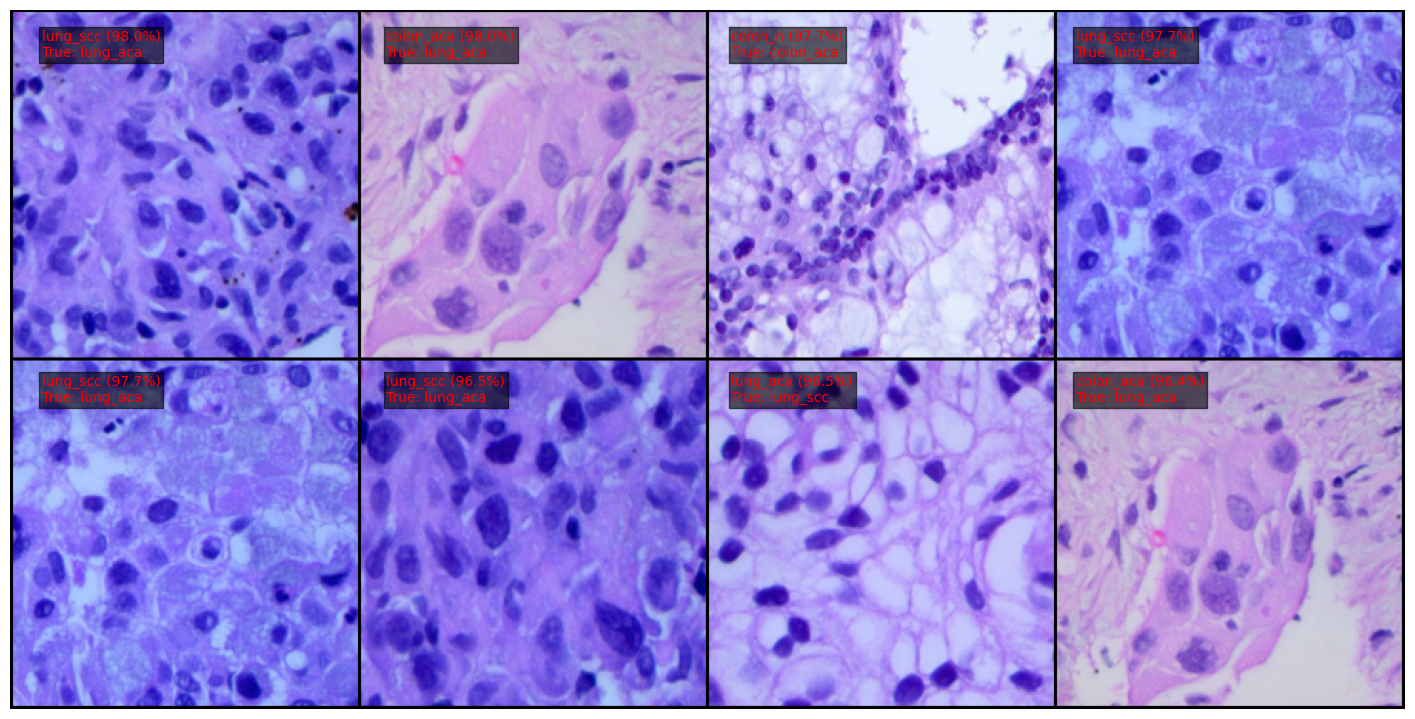

In [ ]:
import matplotlib.pyplot as plt

class_names = train_set.classes
show_worst_predictions(worst_cases, class_names)